# Karakteristik Segmen Pelanggan

## Metodologi

1. **Persiapan Data dan Library**: Memuat dataset hasil olahan (`RFM_dataset.csv`) dan library yang diperlukan.
2. **Penghitungan Nilai Median**: Menghitung median metrik `recency`, `frequency`, dan `monetary` untuk memahami karakteristik setiap segmen.
3. **Visualisasi Perbandingan Segmen**: Menampilkan perbandingan karakteristik antar segmen menggunakan Bar Chart.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

df = pd.read_csv('data/RFM_dataset.csv')

## Menghitung Median

Pada tahap ini, dilakukan penghitungan nilai median untuk metrik `recency`, `frequency`, dan `monetary` pada setiap segmen.

In [2]:
df_median = df.pivot_table(index='segment', values=['recency', 'frequency', 'monetary'], aggfunc='median')

df_median

,frequency,monetary,recency
segment,,,
At Risk,2,890.9050,122.0
Champions,4,1579.5870,21.5
Lost,1,120.7830,187.0
Loyal Customers,3,594.6054,41.0
New / Promising,1,370.1860,40.0


## Visualisasi Perbandingan Metrik RFM antar Segmen

Pada tahap ini, dilakukan visualisasi perbandingan nilai median dari ketiga metrik RFM untuk melihat karakteristik unik dari masing-masing segmen.

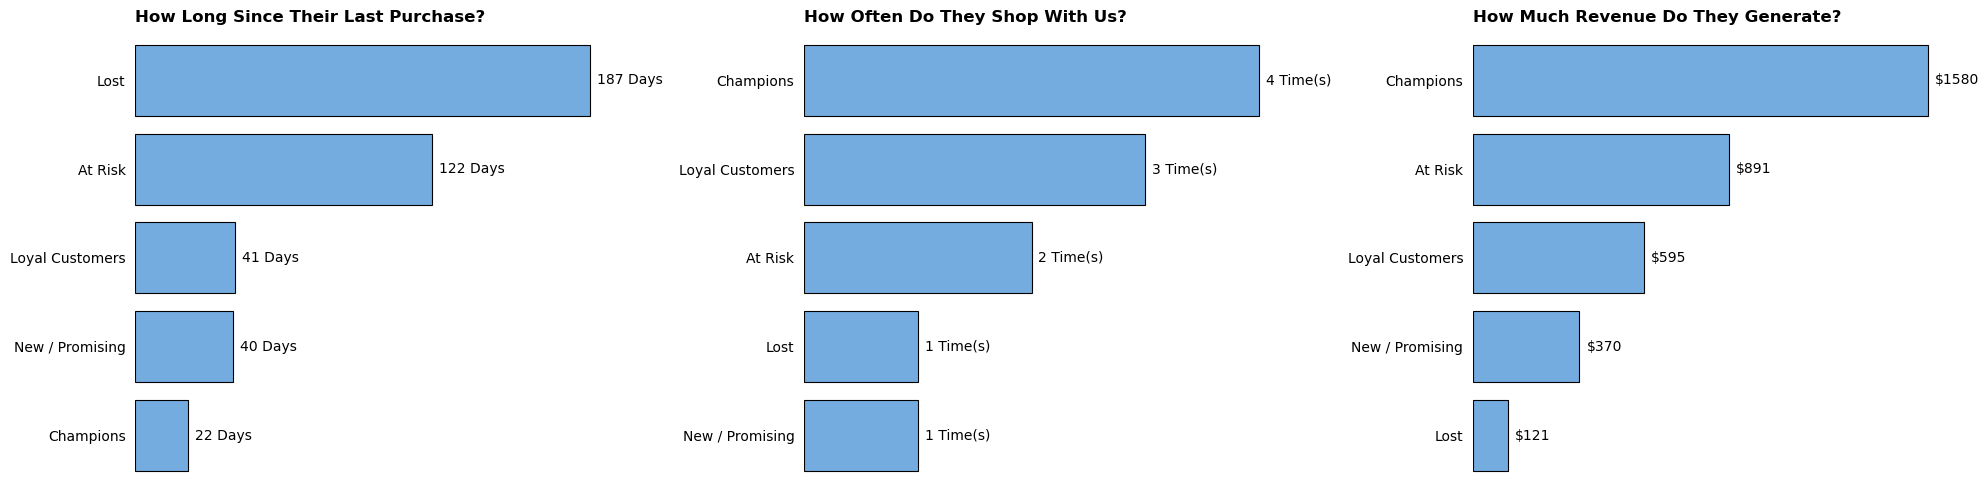

In [3]:
columns = ['recency', 'frequency', 'monetary']
datas = [df_median[column].sort_values(ascending=False) for column in columns]
titles = ['How Long Since Their Last Purchase?', 'How Often Do They Shop With Us?', 'How Much Revenue Do They Generate?']

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

for i in range(len(ax)):
    df_plot = datas[i]
    
    if df_plot.name == 'recency':
        labels = [f'{r:.0f} Days' for r in df_plot.values]
    elif df_plot.name == 'frequency':
        labels = [f'{f:.0f} Time(s)' for f in df_plot.values]
    else:
        labels = [f'${m:.0f}' for m in df_plot.values]
    
    sns.barplot(x=df_plot.values, y=df_plot.index, ax=ax[i], color='#63adf2', ec='black', ls='-', lw=0.8, alpha=1)
    
    title_dict = {'size':12,
              'weight':'bold',
              'color':'black',
              'loc':'left',
              'pad':10,
              'rotation':0,
              'alpha':1,
              'family':plt.rcParams['font.family']}
    
    ax[i].set_title(f'{titles[i]}', **title_dict)
    ax[i].set_ylabel('')
    
    ax[i].tick_params(which='major', axis='both', color='black', direction='out', left=False, bottom=False)
    ax[i].set_xticklabels('')
    
    container = ax[i].containers[0]
    ax[i].bar_label(container=container, labels=labels, size=10, weight='normal', color='black', padding=5)
    
    sns.despine(left=True, bottom=True, ax=ax[i])

plt.tight_layout()
plt.show()